# Program prognozujący rozwój gruźlicy oraz kiły w Polsce

In [21]:
import numpy as np
import pandas as pd
import scipy as s
import math
import matplotlib.pyplot as plt

## Prognozowanie gruźlicy
### Prognoza zachorowań na gruźlicę w grupie mężczyzn w wieku 50-59 lat przy użyciu modelu SEIS na 20 lat w oparciu o dane z 2009 roku

### Pobranie danych i ich wyfiltrowanie

In [22]:
dane = pd.read_excel("zachorowania_na_gruzlice_pluc_2009-2024.xlsx",sheet_name = 'dane')

In [23]:
dane_filtr = dane.query("plec == 'Mężczyźni' and grupy_wieku == 'od 50 do 59 lat '")

In [24]:
N = 2772100 # liczba wszystkich mężczyzn żyjących w Polsce w 2009 roku w wieku od 50 do 59 lat
I0 = math.ceil(dane.query("plec == 'Mężczyźni' and grupy_wieku == 'od 50 do 59 lat ' and rok == 2009")["wartosc"].iloc[0]) # grupa zakażonych - liczba zahorowań na gruźlicę
# w badanej grupie wiekowej w 2009 roku
E0 = 10*I0 # grupa narażonych - szacunkowa ilość osób zainfekowanych, u których choroba znajduje się w okresie utajenia (inkubacji)
S0 = N - I0 - E0 # grupa podatnych - liczba wszystkich mężczyzn żyjących w Polsce w 2009 roku w wieku od 50 do 59 lat, którzy nie należą do grup I0 oraz E0

### Model SEIS - opis parametrów

In [25]:
R0 = 0.8  # współczynnik epidemii (podstawowa liczba odtwarzania) -> określa ile srednio osób zarazi jeden chory
          # człowiek, jeśli wejdzie do całkowicie zdrowej populacji
b = 1/0.5 # współczynnik zdrowienia osobników zainfekowanych -> odwrotność średniego czasu trwania aktwynej fazy
          # u wykrytego pacjenta do momentu zaleczenia (szacuje się pół roku)
mi = 1/71 # współcznik narodzin/śmiertelności -> odwrotność średniego wieku życia mężczyzn w Polsce (71 lat)
d = 1/4 # wspóŁczynnik zainfekowania osobników z ukrytą fazą choroby -> odwrotność średniego czasu
          # przebywania w grupie E (wynosi od około 2 do 5 lat)
a = R0 * ((d+mi)*(b+mi))/d # tempo rozprzestrzeniania się infekcji

### Model SEIS - układ równań

In [26]:
def uklad(z,t,a,b,mi,d):
    S,E,I = z
    dSdt = mi*N-a*(S/N)*I-mi*S+b*I
    dEdt = a*(S/N)*I - (d+mi)*E
    dIdt = d*E-(b+mi)*I
    return[dSdt,dEdt,dIdt]

### Rozwiązanie układu, prognoza zachorowań na gruźlicę w badanej grupie wiekowej na 20 lat oraz wykres zakażeń w danym roku

In [27]:
z0 = [S0, E0, I0]
t = np.linspace(2009,2030,21)

roz = s.integrate.odeint(uklad, z0, t,args = (a,b,mi,d))

S_roz = roz[:,0]
E_roz = roz[:,1]
I_roz = roz[:,2]

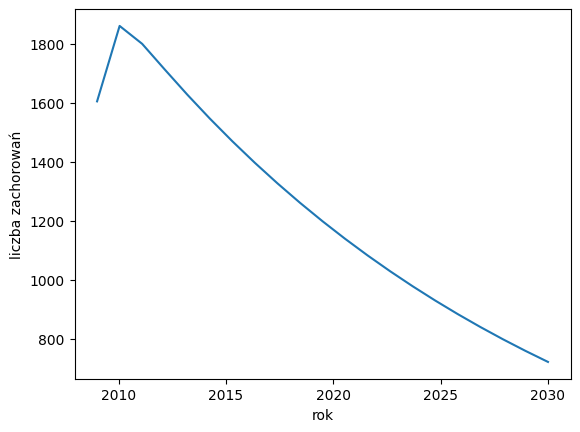

In [28]:
plt.plot(t,I_roz)
plt.xlabel('rok')
plt.ylabel('liczba zachorowań')
plt.show()

### Wyprintowanie prognozowanej liczby rocznej zakażeń na gruźlicę w badanej grupie wiekowej w poszczególnych latach

In [29]:
lata_do_sprawdzenia = [1, 5, 10, 15, 20]
kroki_na_rok = len(t) // 20

for rok in lata_do_sprawdzenia:
    indeks = rok * kroki_na_rok - 1
    zakazeni = int(I_roz[indeks])
    print(f"W {2009+rok} roku: {zakazeni} osób")

W 2010 roku: 1605 osób
W 2014 roku: 1628 osób
W 2019 roku: 1261 osób
W 2024 roku: 978 osób
W 2029 roku: 759 osób


### Wnioski: w oparciu o model SEIS roczna liczba zachorowań na gruźlicę w badanej grupie zaliczy niewielki wzrost w stosunku do 2009 przez pierwsze 2 lata, potem nastąpi systematyczny spadek rocznej liczby zachorowań, po dwudziestu latach będzie to spadek o 50% w stosunku do 2009 roku.

## Prognozowanie kiły
### Prognoza zachorowań na kiłę w grupie mężczyzn w wieku 25-29 lat przy użyciu modelu SIS na 20 lat w oparciu o dane z 2009 roku

### Pobranie danych i ich wyfiltrowanie

In [30]:
dane1 = pd.read_excel("zachorowania_na_kile_2009-2024.xlsx",sheet_name = 'dane')

In [31]:
dane1_filtr = dane1.query("plec == 'Mężczyźni' and grupy_wieku == 'od 25 do 29 lat '")

In [32]:
N1 = 1662200 # liczba wszystkich mężczyzn żyjących w Polsce w 2009 roku w wieku od 256 do 29 lat
I01 = math.floor(N1*(dane1.query("plec == 'Mężczyźni' and grupy_wieku == 'od 25 do 29 lat ' and rok == 2009")["wartosc"].iloc[0])/100000) # grupa zakażonych - wyliczona
# liczba zachorowań na kiłę w badanej grupie wiekowej w 2009 roku
S01 = N1 - I01 # grupa podatnych - liczba wszystkich mężczyzn żyjących w Polsce w 2009 roku w wieku od 50 do 59 lat, którzy nie są zainfekowani

### Model SIS - opis parametrów

In [33]:
b1 = 1/(2) # współczynnik zdrowienia osobników zainfekowanych -> odwrotność średniego czasu trwania aktwynej fazy
          # u wykrytego pacjenta do momentu zaleczenia (szacuje się pół roku)
a1 = 0.58 # wspolczynnik narodzin/smiertelnosci
# współczynnik mi zostaje taki sam, jak w poprzednim modelu

### Model SIS - układ równań

In [34]:
def uklad1(z,t,a1,b1,mi):
    S,I = z
    dSdt = -a1*(S/N1)*I+mi*(N1-S)+b1*I
    dIdt = a1*(S/N1)*I-(b1+mi)*I
    return[dSdt,dIdt]

### Rozwiązanie układu, prognoza zachorowań na kiłę w badanej grupie na 20 lat oraz wykres zakażeń w danym roku

In [35]:
z01 = [S01, I01]
t1 = np.linspace(2009,2030,21)

roz = s.integrate.odeint(uklad1, z01, t1, args = (a1,b1,mi))

S_roz1 = roz[:,0]
I_roz1 = roz[:,1]

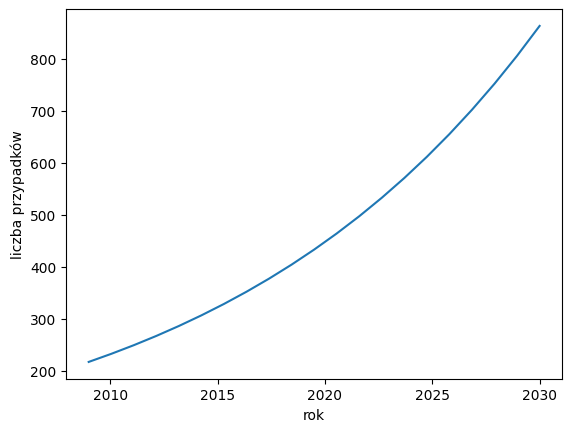

In [36]:
plt.plot(t1,I_roz1)
plt.xlabel('rok')
plt.ylabel('liczba przypadków')
plt.show()

### Wyprintowanie prognozowanej liczby rocznej zakażeń na kiłę w badanej grupie wiekowej w poszczególnych latach

In [37]:
lata_do_sprawdzenia = [1, 5, 10, 15, 20]
kroki_na_rok = len(t) // 20

for rok in lata_do_sprawdzenia:
    indeks = rok * kroki_na_rok - 1
    zakazeni = int(I_roz1[indeks])
    print(f"W {2009+rok} roku: {zakazeni} osób")

W 2010 roku: 217 osób
W 2014 roku: 286 osób
W 2019 roku: 404 osób
W 2024 roku: 570 osób
W 2029 roku: 805 osób


### Wnioski: w oparciu o model SIS roczna liczba zachorowań na kiłę w badanej grupie zaliczy znaczący wzrost w stosunku do 2009, po dwudziestu latach będzie to wzrost niemalże czterokrotny, z poziomu ok. 200 do ok. 800 zakażeń rocznie.